# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [36]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [4]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


In [37]:
df = pd.read_csv("zillow_dataset.csv")

## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


The objective of this project is to build a data‑driven model that can predict the market value of residential properties using publicly available housing characteristics. For Zillow, this supports the business goal of improving the accuracy and consistency of home‑value estimates, which helps attract home sellers, buyers, real‑estate partners, and advertisers. A more reliable valuation model strengthens user trust in Zillow’s platform and enables better pricing recommendations, engagement, and product personalization.

**1.2:**  How will your solution be used?


The solution will be used to estimate property values for homes that are not currently on the market or do not have recent comparable sales. Marketing teams can highlight price trends, personalize recommendations, and segment customers based on predicted home values. Product teams can integrate the model into Zillow’s search experience to help buyers and sellers make more informed decisions. The estimates can also support internal forecasting, inventory analysis, and regional market assessments.

**1.3:**  How should success (or failure) be measured?


Success means achieving strong regression performance — such as a low RMSE on a held‑out test set and minimal systematic bias across regions or property types. From a business perspective, success means the model’s predictions meaningfully improve user engagement, trust, and decision‑making. Indicators may include more accurate valuations compared to actual sale prices, higher user interaction with valuation tools, or reduced customer complaints about valuation accuracy. Failure would be indicated by poor predictive accuracy or a model that introduces inconsistent or misleading price estimates.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [38]:
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [40]:
df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

In [41]:
df.isnull().sum()

parcelid                            0
airconditioningtypeid           52606
architecturalstyletypeid        77406
basementsqft                    77563
bathroomcnt                        34
bedroomcnt                         34
buildingclasstypeid             77598
buildingqualitytypeid           27804
calculatedbathnbr                 650
decktypeid                      76999
finishedfloor1squarefeet        71576
calculatedfinishedsquarefeet      235
finishedsquarefeet12             3690
finishedsquarefeet13            77571
finishedsquarefeet15            74586
finishedsquarefeet50            71576
finishedsquarefeet6             77227
fips                               34
fireplacecnt                    69324
fullbathcnt                       650
garagecarcnt                    52093
garagetotalsqft                 52093
hashottuborspa                  76074
heatingorsystemtypeid           28042
latitude                           34
longitude                          34
lotsizesquar

In [42]:
df.shape[0]

77613

In [43]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

numeric_categoricals = [
    col for col in numeric_cols
    if (
        df[col].nunique() <= 30   
    )
]

num_cols = [col for col in numeric_cols if col not in numeric_categoricals]
cat_cols = (
    df.select_dtypes(include=["object", "category"]).columns.tolist()
    + numeric_categoricals
)


#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

In [44]:
cat_cols

['hashottuborspa',
 'propertycountylandusecode',
 'propertyzoningdesc',
 'fireplaceflag',
 'taxdelinquencyflag',
 'airconditioningtypeid',
 'architecturalstyletypeid',
 'bathroomcnt',
 'bedroomcnt',
 'buildingclasstypeid',
 'buildingqualitytypeid',
 'calculatedbathnbr',
 'decktypeid',
 'finishedsquarefeet13',
 'fips',
 'fireplacecnt',
 'fullbathcnt',
 'garagecarcnt',
 'heatingorsystemtypeid',
 'poolcnt',
 'pooltypeid10',
 'pooltypeid2',
 'pooltypeid7',
 'propertylandusetypeid',
 'regionidcounty',
 'roomcnt',
 'storytypeid',
 'threequarterbathnbr',
 'typeconstructiontypeid',
 'unitcnt',
 'numberofstories',
 'assessmentyear',
 'taxdelinquencyyear']

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

There are a number of features that are arguably useless in the context of this project. For example, pooltypeid2 and pooltypeid7 are redundant - one is an indicator of the pool having a hottub or spa, whereas pooltypeid7 represents the pool not having a hottub or spa. Quite frankly - this makes no sense since the fields are split to either be true or NULL - they do not need to be split out. To add to this, there is the rawcensustractandblock field, which is just a less informative version of the censustractandblock field - not only will the two be almost perfectly linearlly dependant - but one is simply inferior to the other. 

I do question whether this information is even of any statistical use in the valuation of a property, but like many of the fields here, although their statistical significance may be very minor, there may still be an effect on the target variable. Examples of this include: yardbuldingsqft26, which is the square footage of the 26th yard building, should have little impact on predicting property price considering the vast majority of proprties will not have a 26th yard building, but it's not impossible there is an effect of proprty value. There are also features such as airconditionertypeid that identify the type of air conditioner installed in the home, which I would think might be a very minor feature with little impact, but we think of a scenario such as one air conditioner type being so top of the line that it has a strong impact on the house's price. In this manner, I do feel like their is at least some utility to the majority of fields here. What concerns us in this regard is that these are formatted as numerical type ID fields, often with a very wide range of unique values - considering we do not have any sort of type index for these IDs - it may be best to not include them.

Two other features that are unimportant are those surrounding taxdelinquency - these do not provide any insight into the property value, but rather describe the behavior of the previous/current homeowners. 

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

There are cetainly features that appear to be useless because of the percentage of missing values. The percentage of NULL values on several columns, such as architecturalstyletypeid, basementsqft, decktypeid, and finishedsquarefeet13/15 all have over 99% NULL values. There are several other features consisting of well over 50% NULL values. This is going to require setting a threshold for the percentage of NULL values, which is up to us to decide. Anything over 90% is simply useless, although as stated below there is nuance within a feature such as hashottuborspa, which seems to only have a value if it's True, and is null if it does not - imputing a value of 0 for null values may "save" that feature, but this is also dependant on ordering the imputation function prior to the drop function. To set this threshold - we consider that generally ML models will set a threshold at around 50%, but we can (and should) take a more conservative approach here considering there are so many features with high-percentages of null values.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

Yes - there are multiple features that appear useless due to the number of unique values. For example, there are several features with only one unique value, such as taxdelinquencyflag, decktypeid, and hashottuborspa. Even if a feature has a binary (y/n, 1/0, true/false) value, there should at least be two - nontheless, a feature such as hashottuborspa may be able to be preserved through imputing a 0 value on nulls. I'd also say that basementsqft has a concerning number of nulls. Considering it is a continuous numerical variable and only has 43 unique values, it is highly likely that there are very few records where that feature is not null. 

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

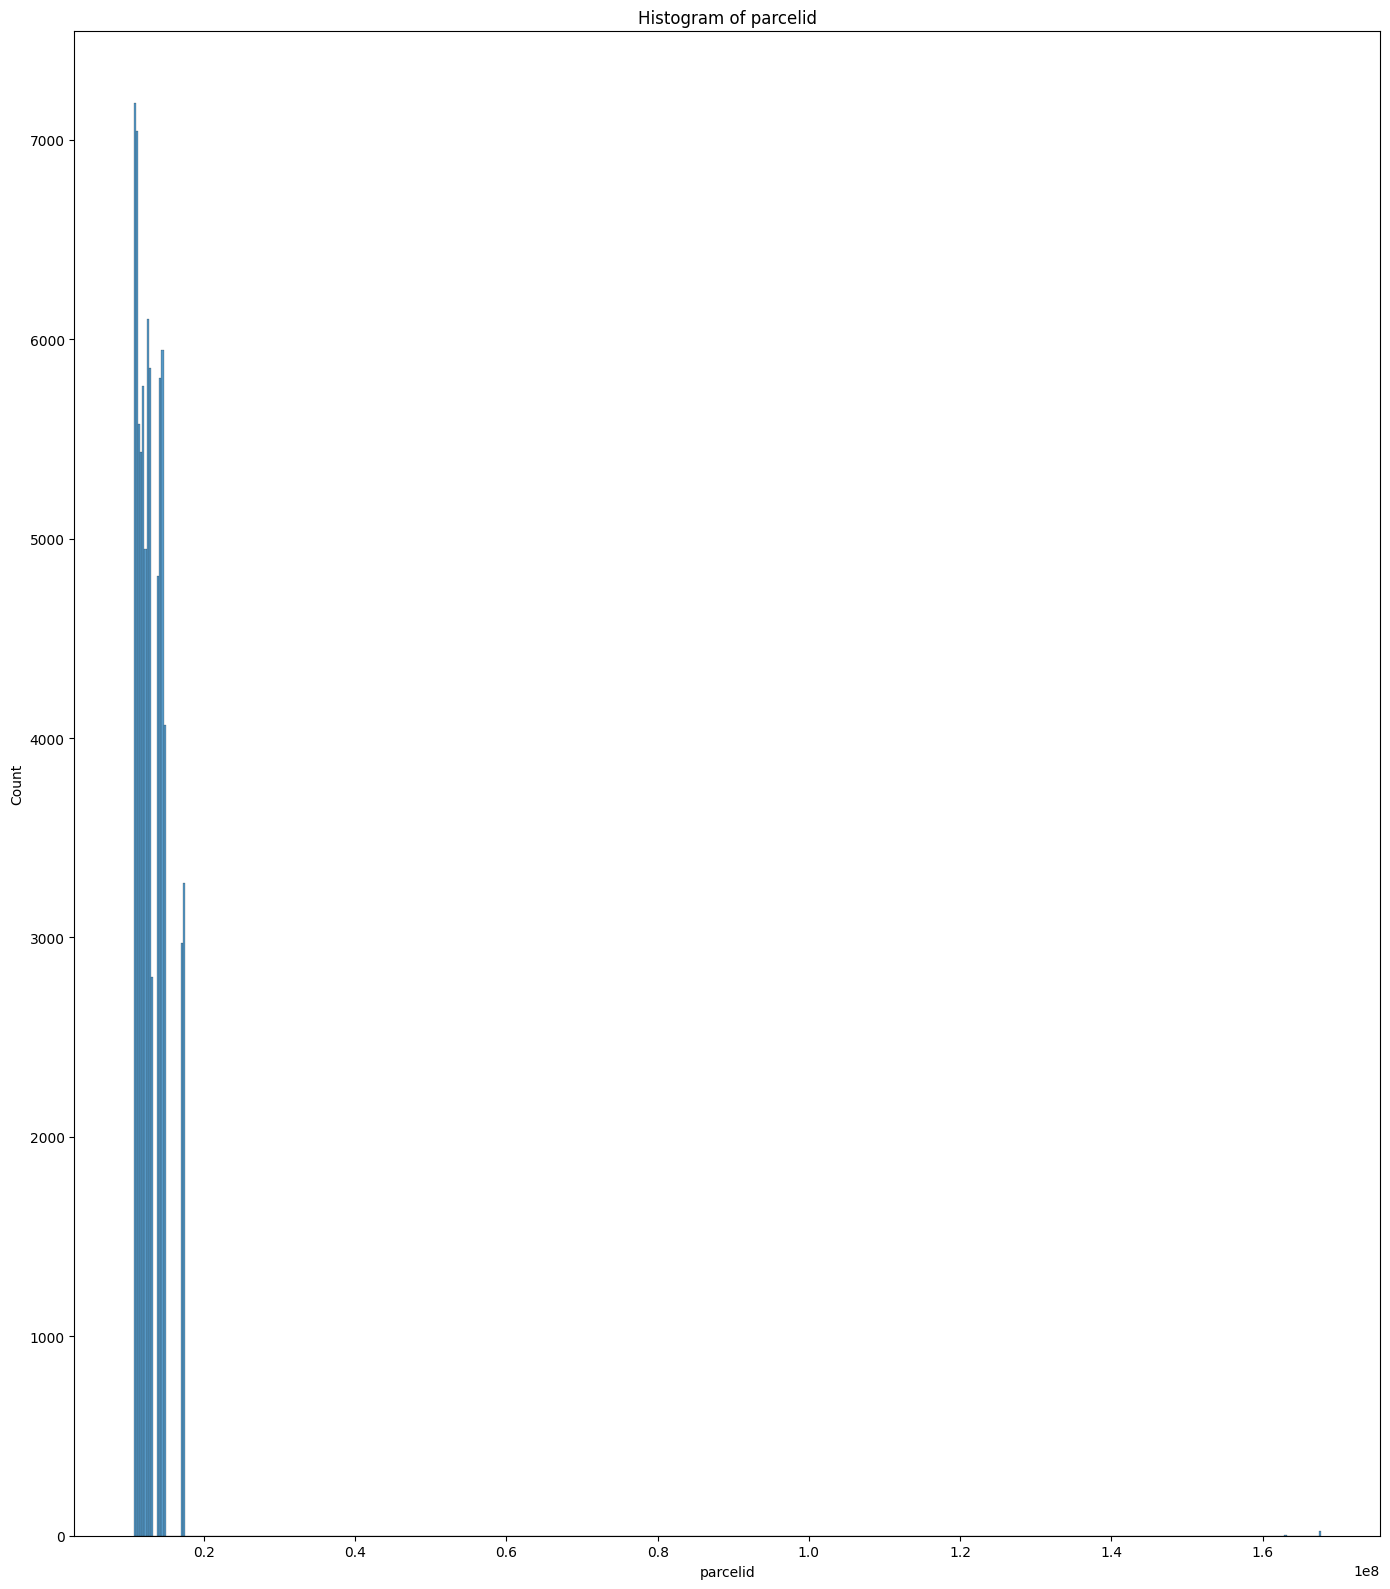

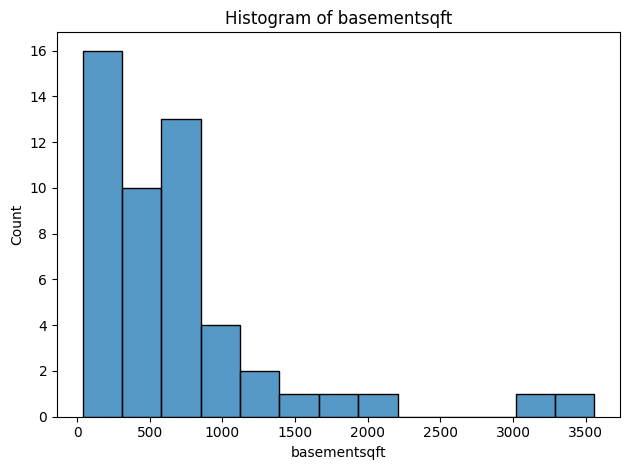

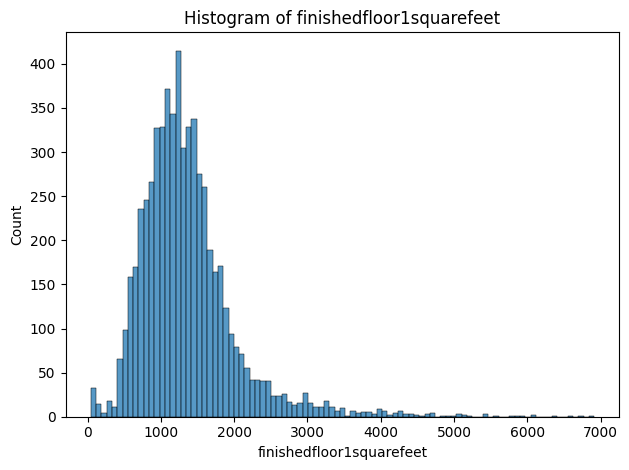

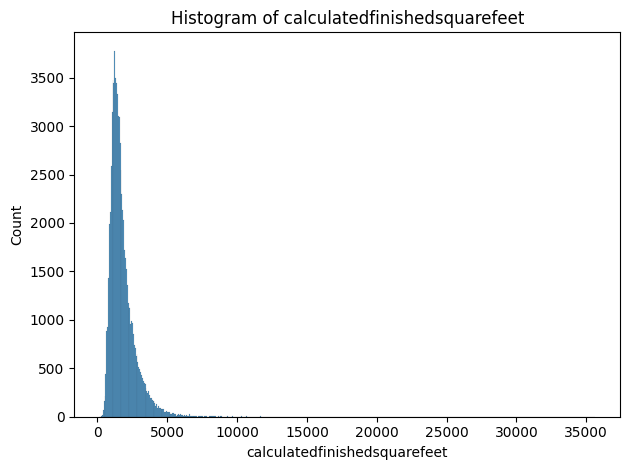

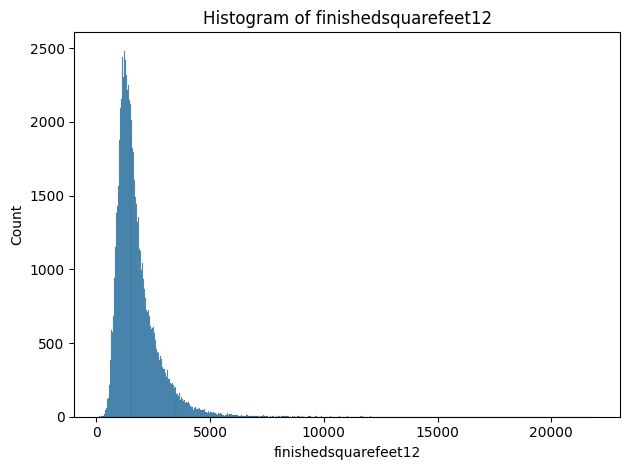

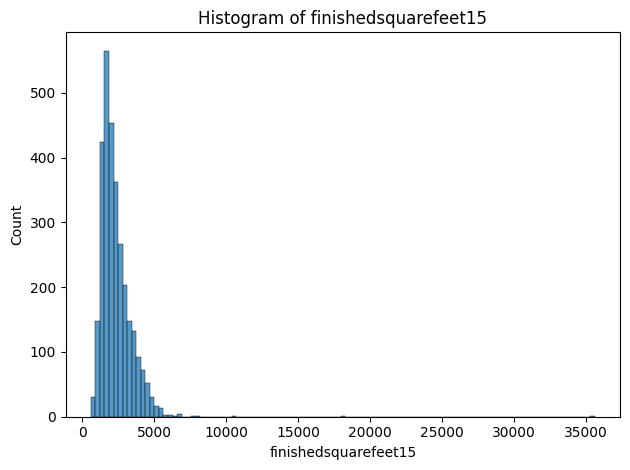

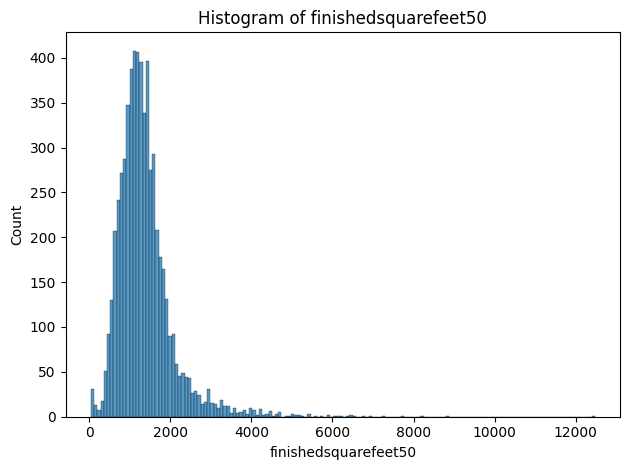

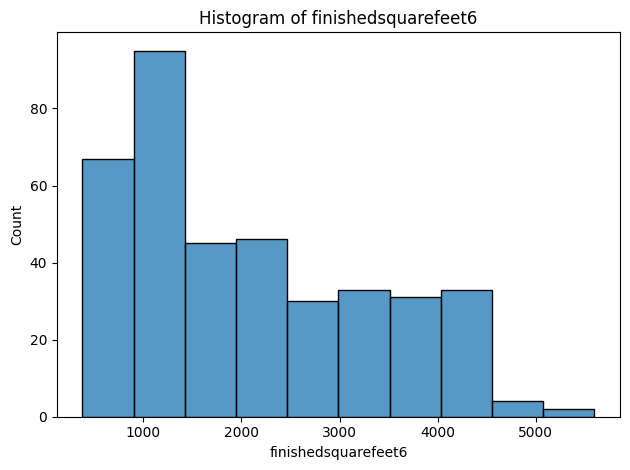

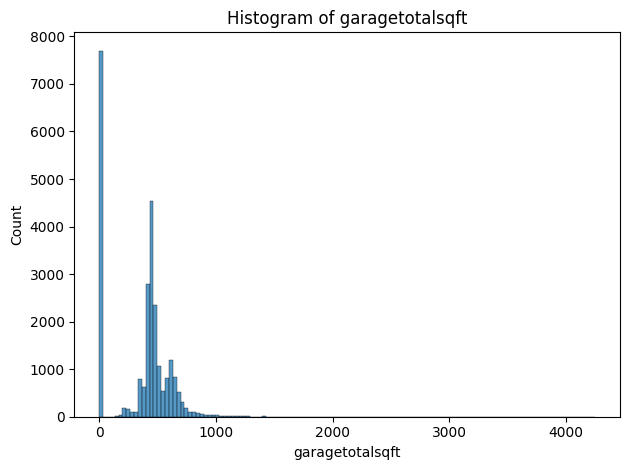

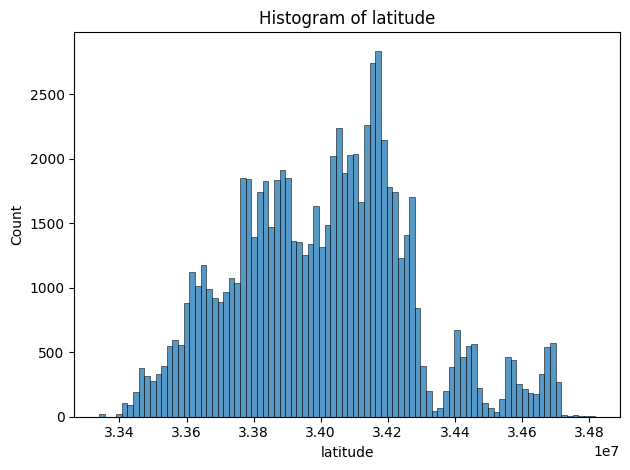

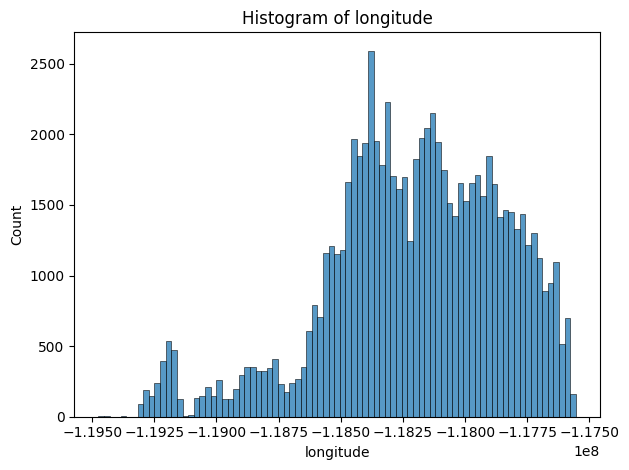

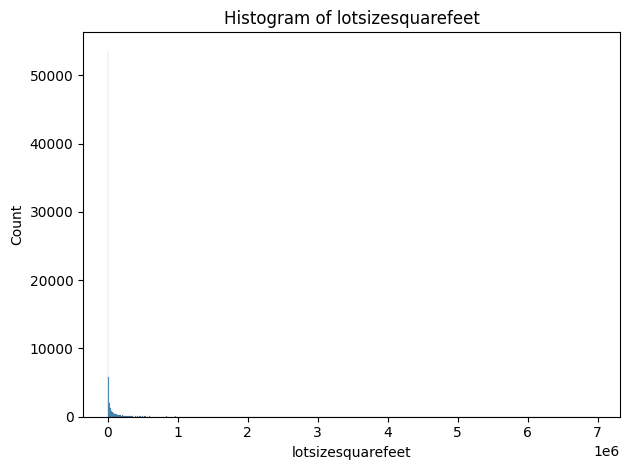

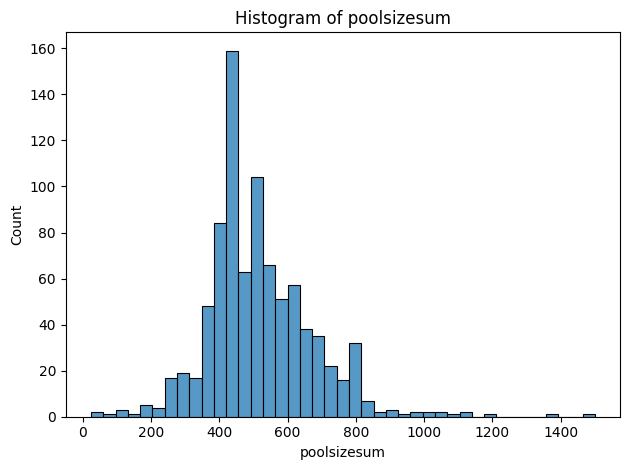

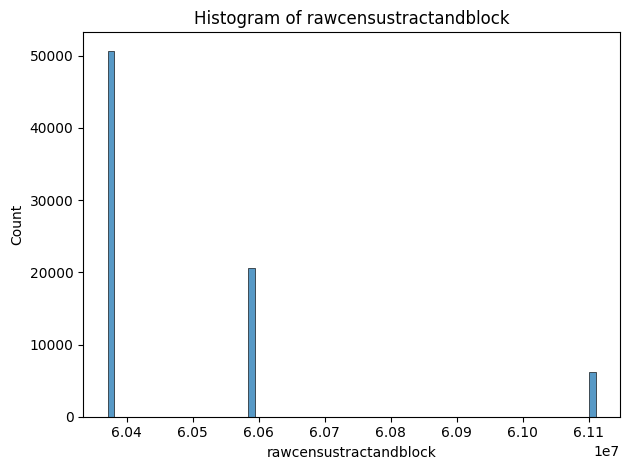

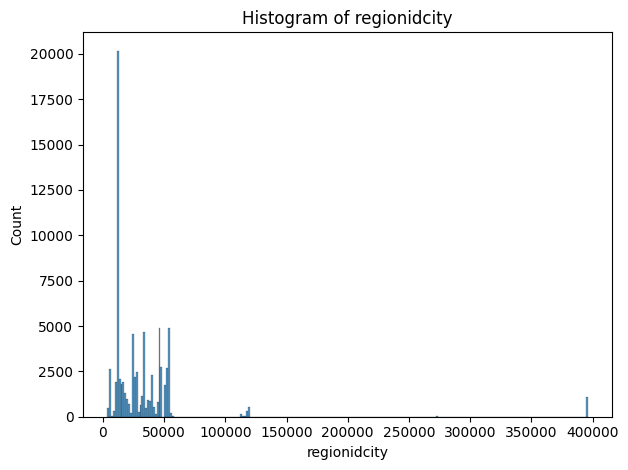

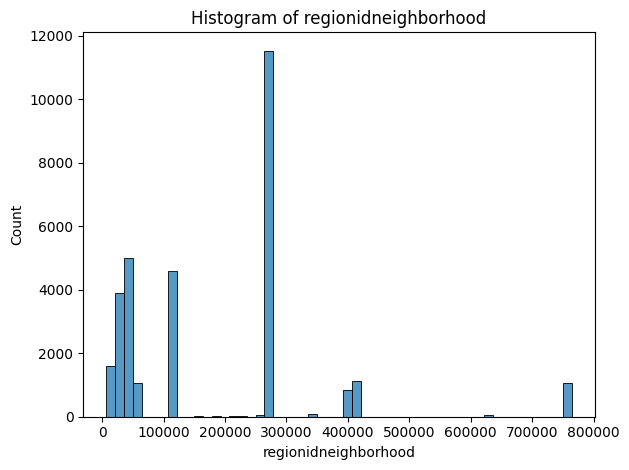

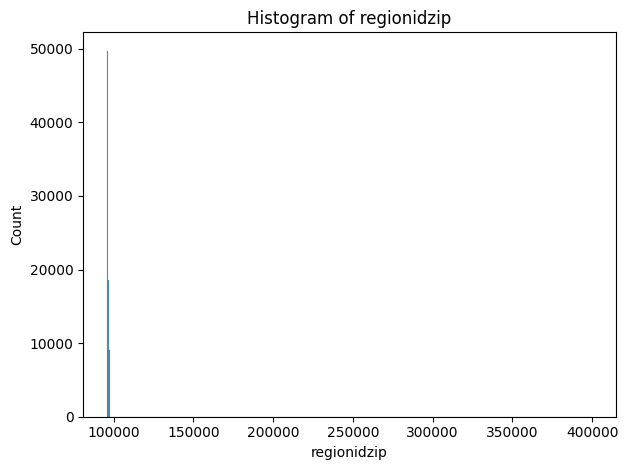

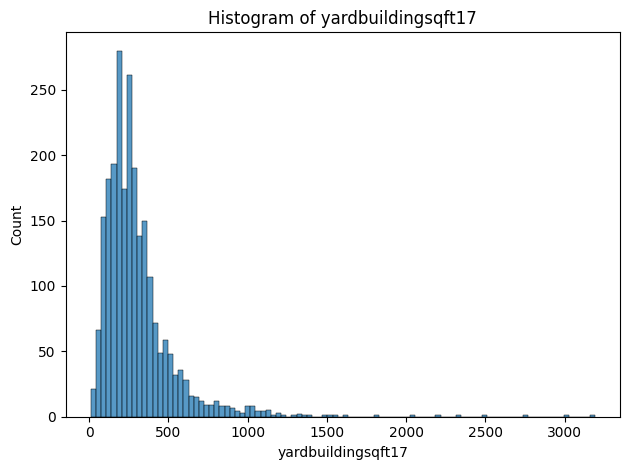

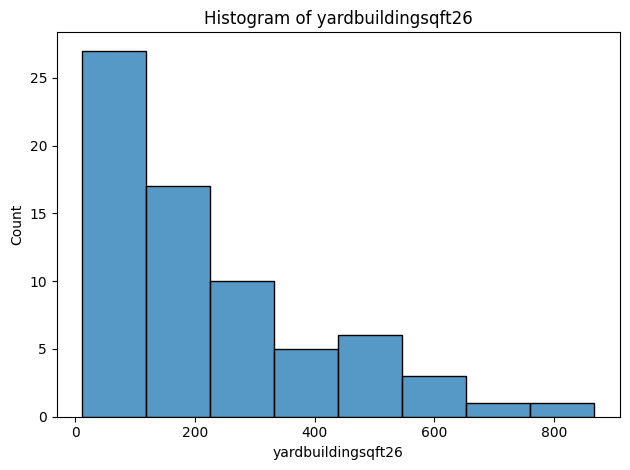

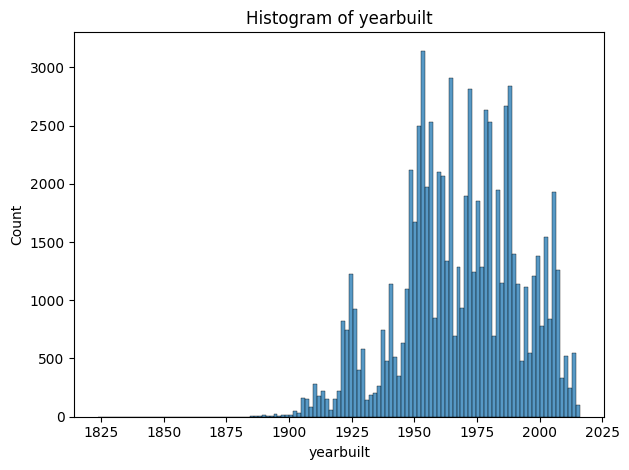

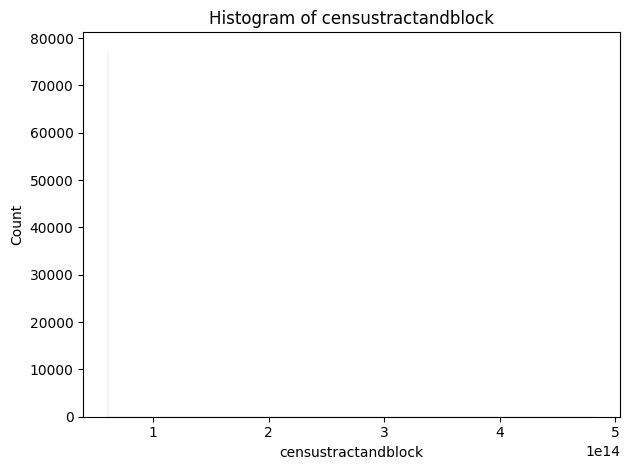

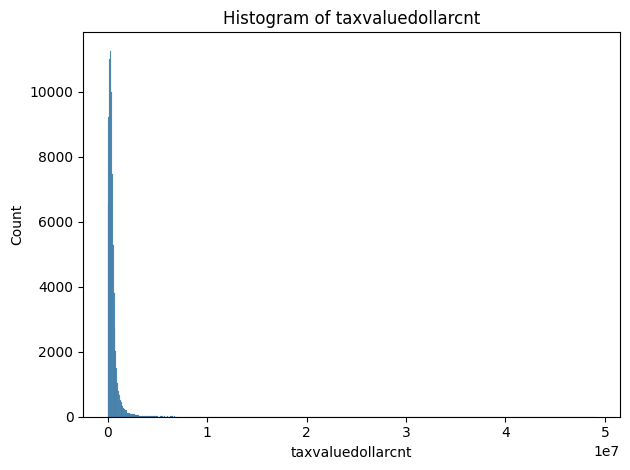

In [45]:
#for col in df.select_dtypes(include="number"):
   # if df[col].nunique() > 10:
    #    cat_cols = cat_cols.append(pd.Index([col]))

import matplotlib.pyplot as plt
plt.figure(figsize=(14, 16))

for col in num_cols:
        sns.histplot(
        data=df,
        x=col
        )

    
        plt.title(f"Histogram of {col}")
        plt.tight_layout()
        plt.show()

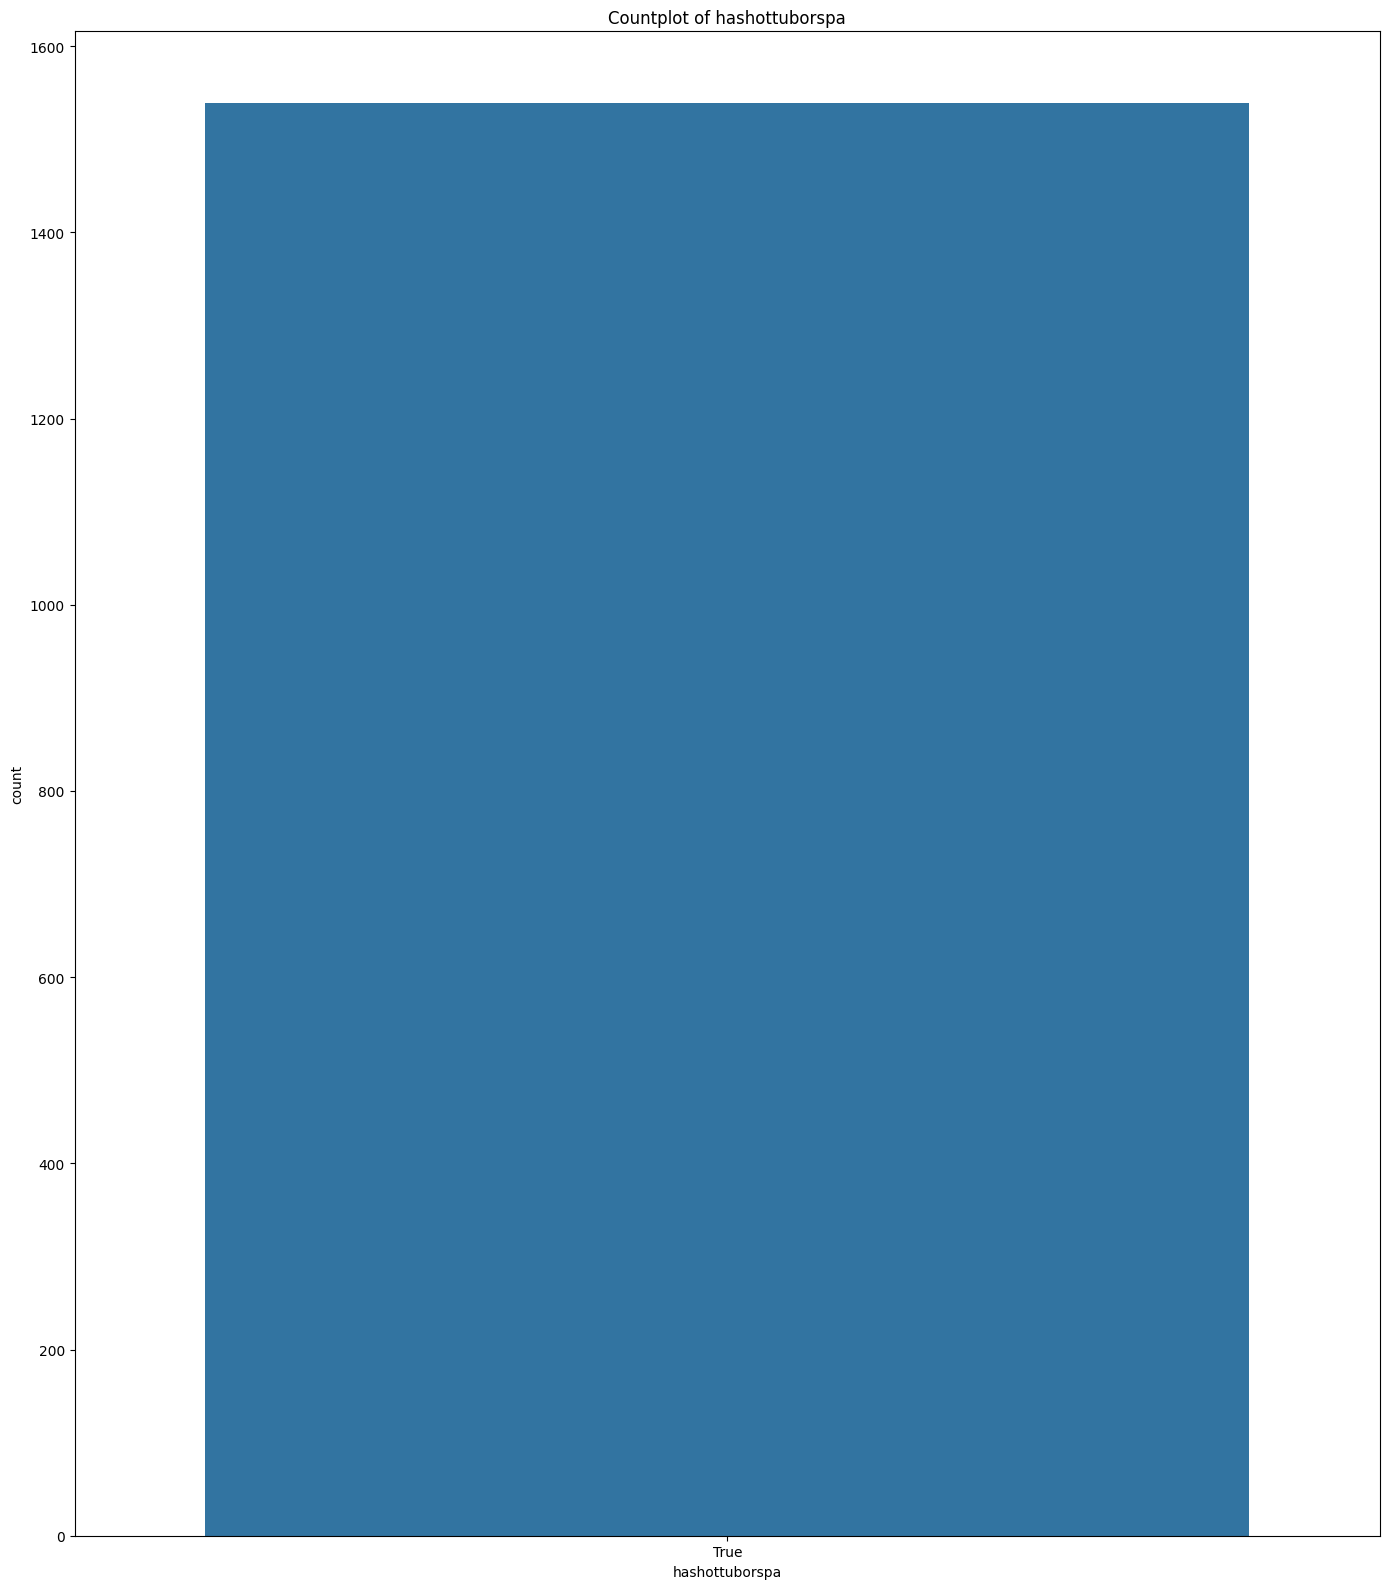

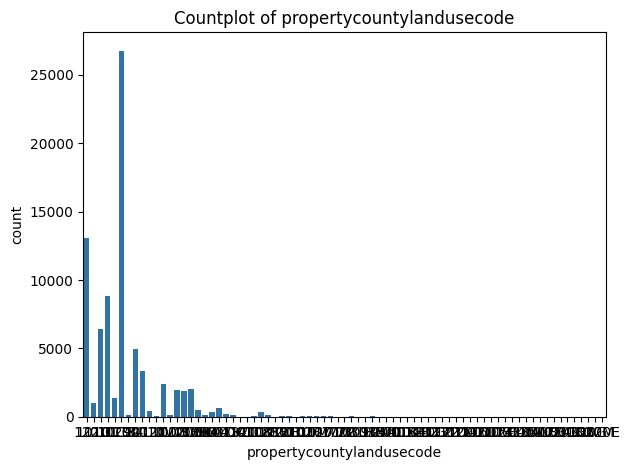

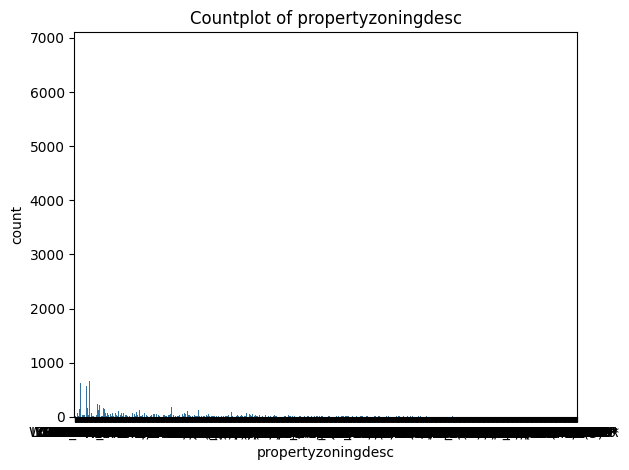

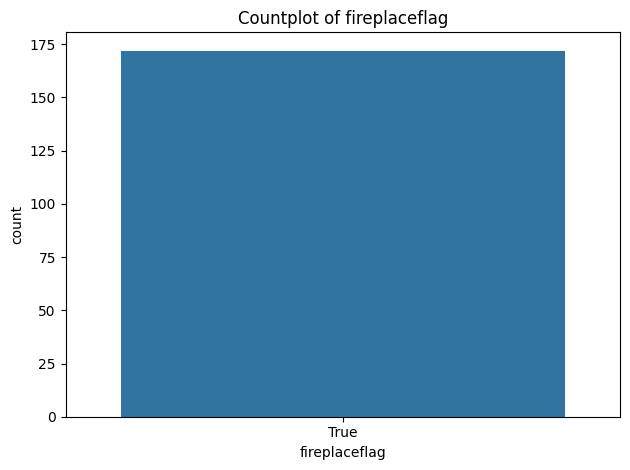

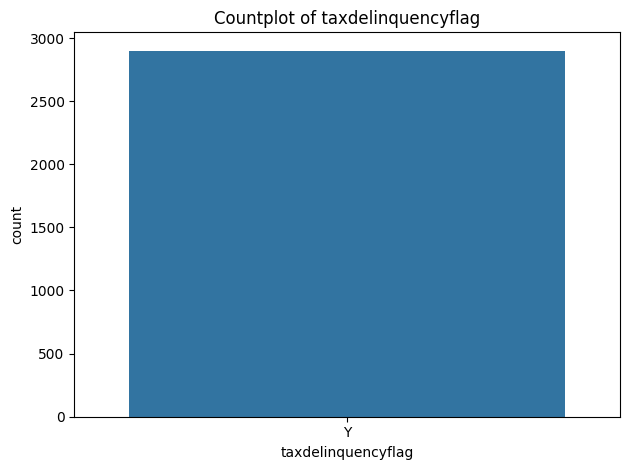

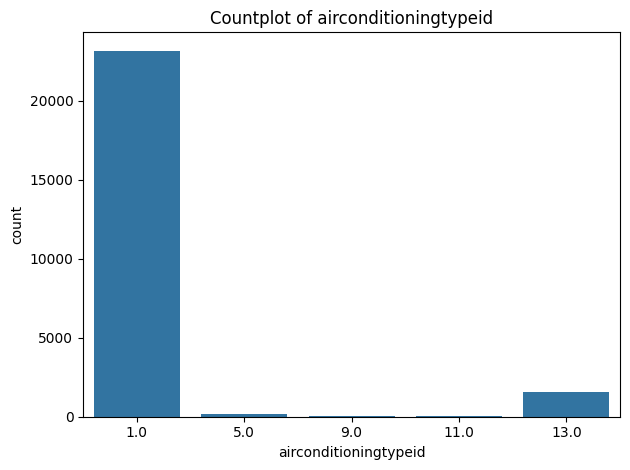

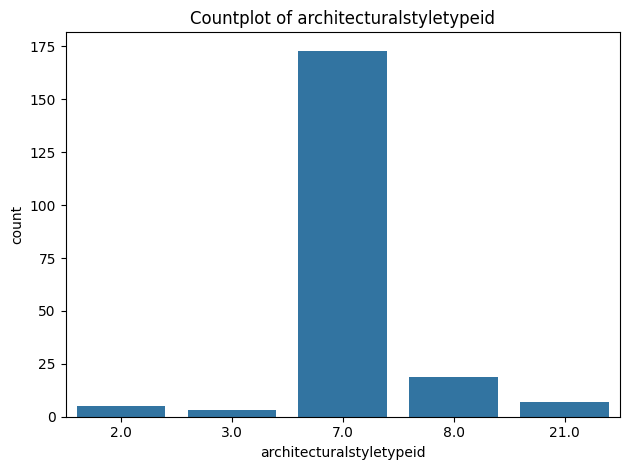

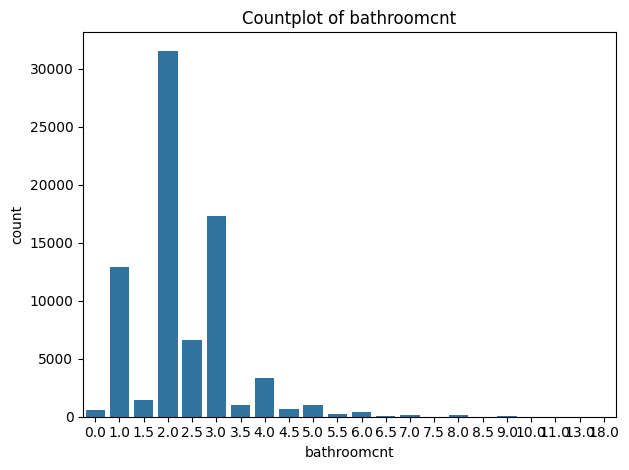

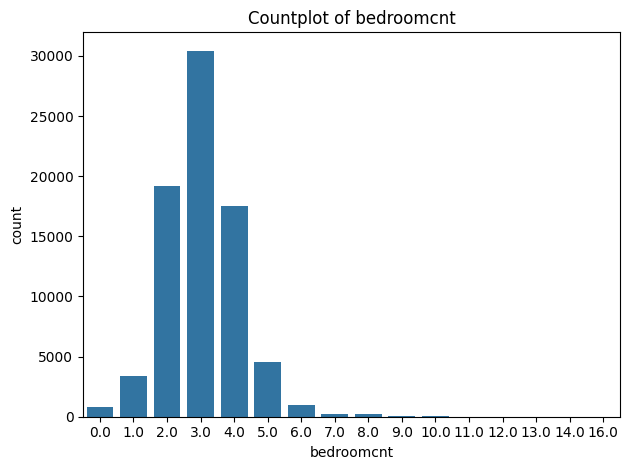

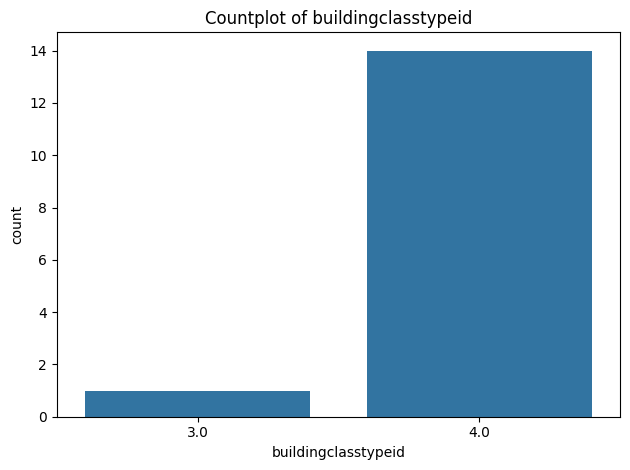

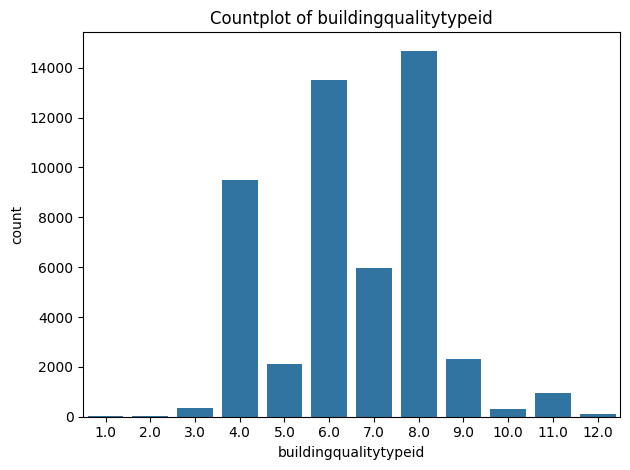

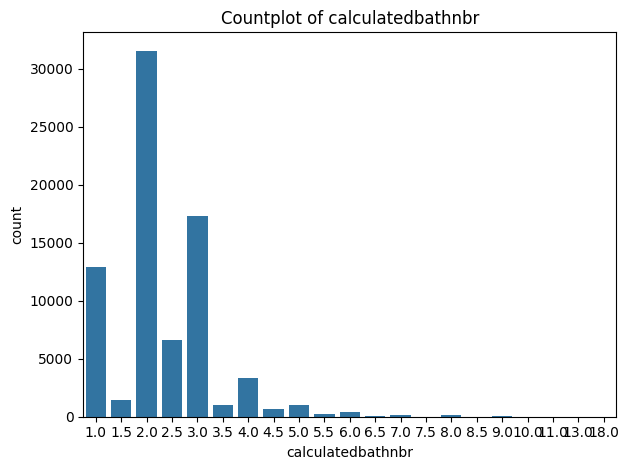

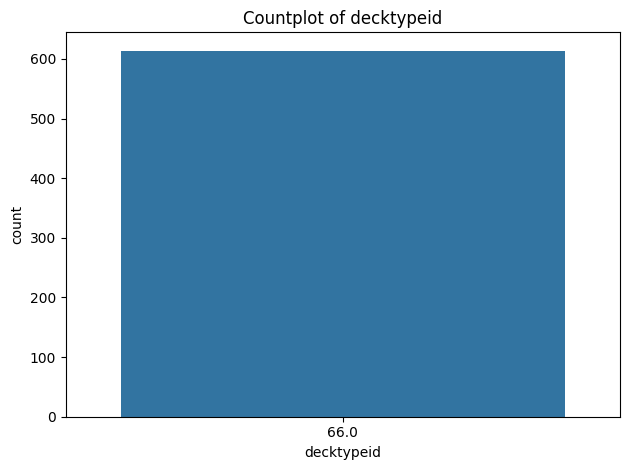

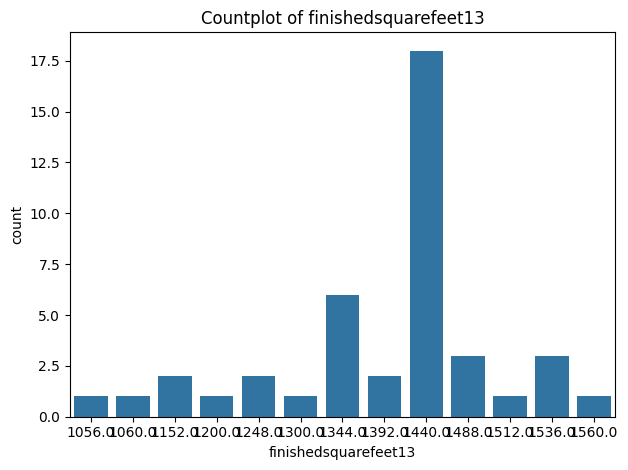

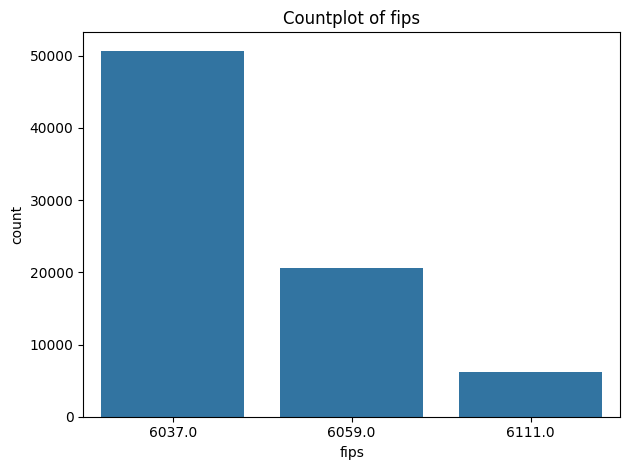

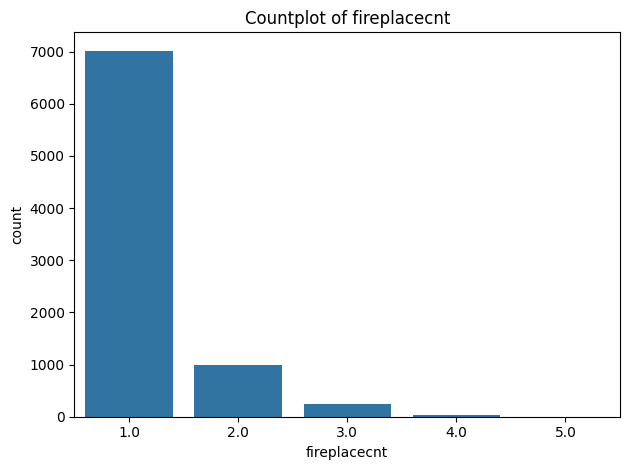

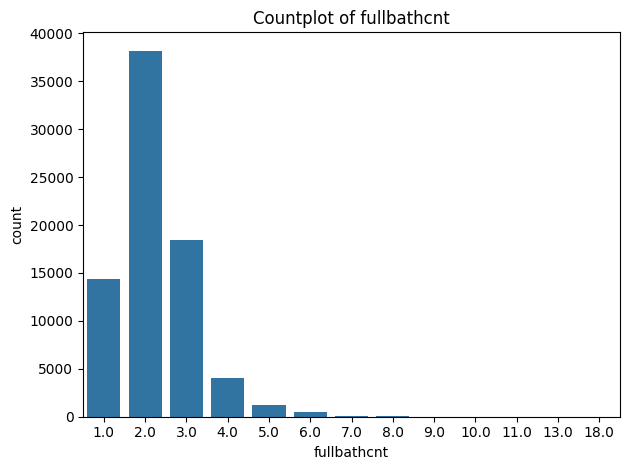

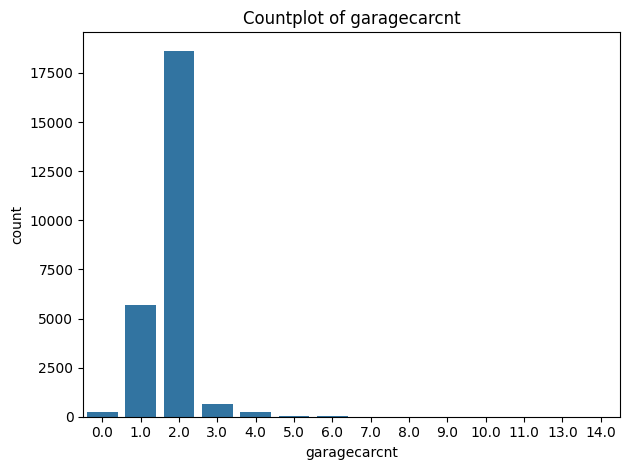

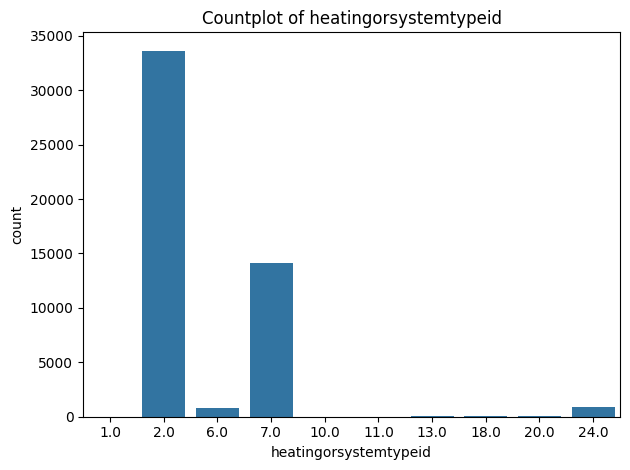

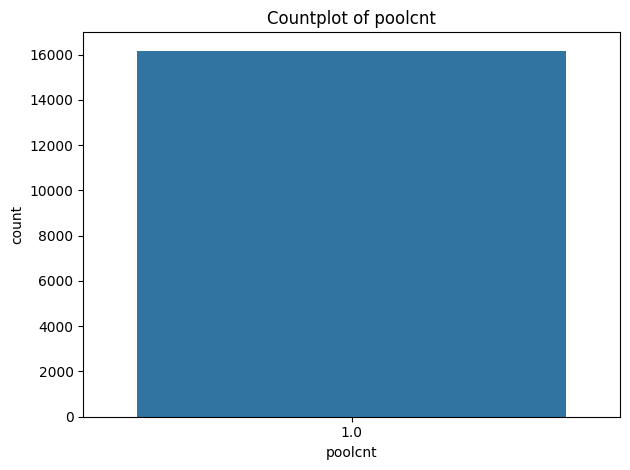

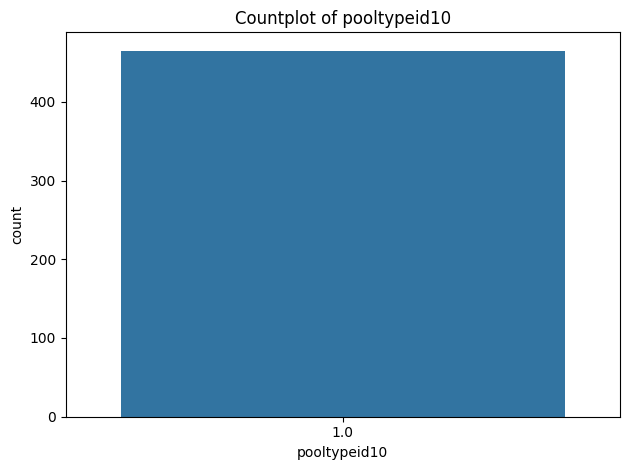

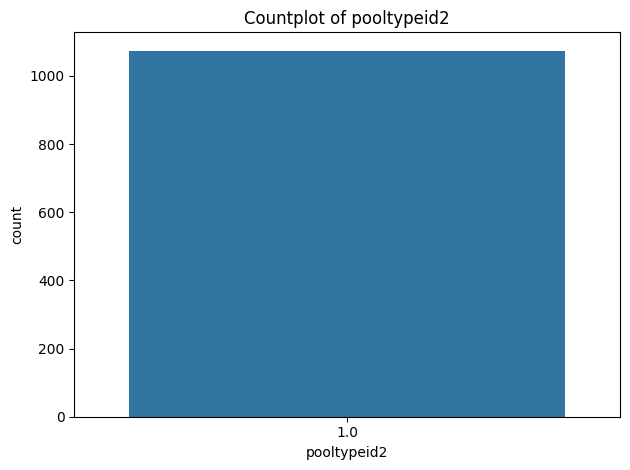

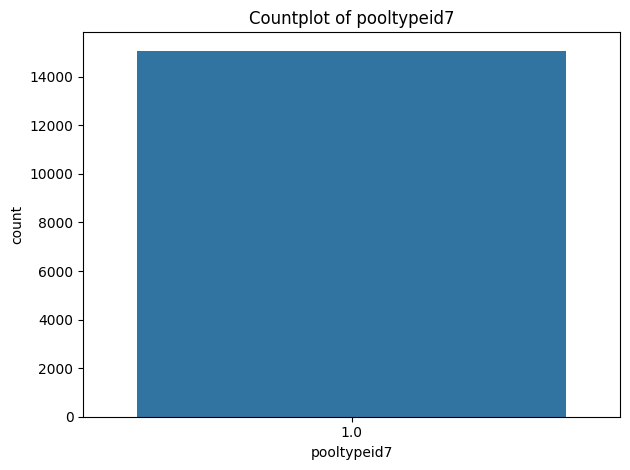

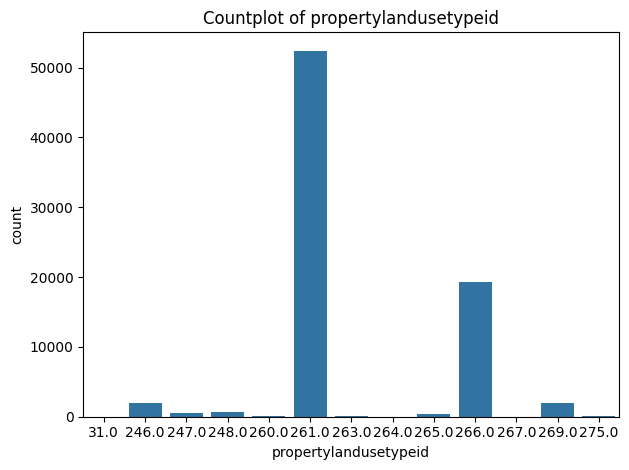

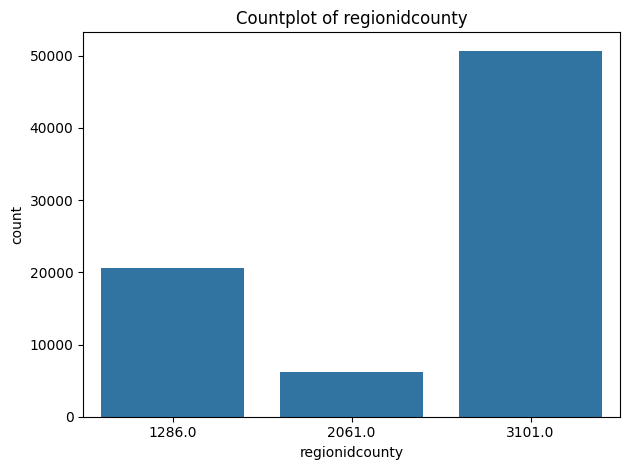

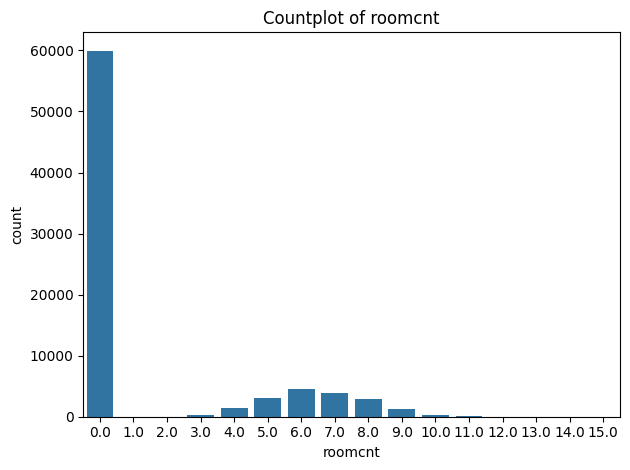

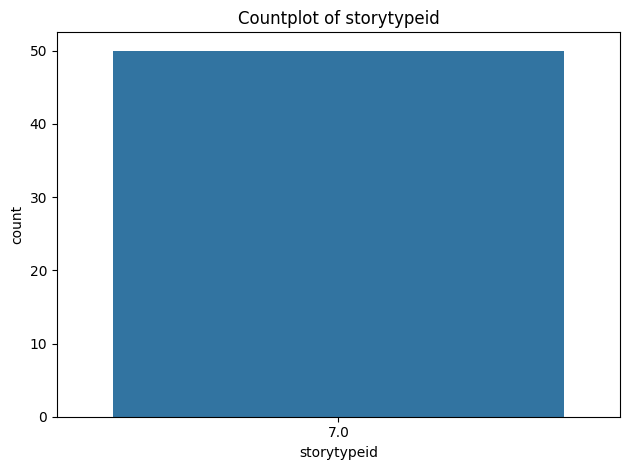

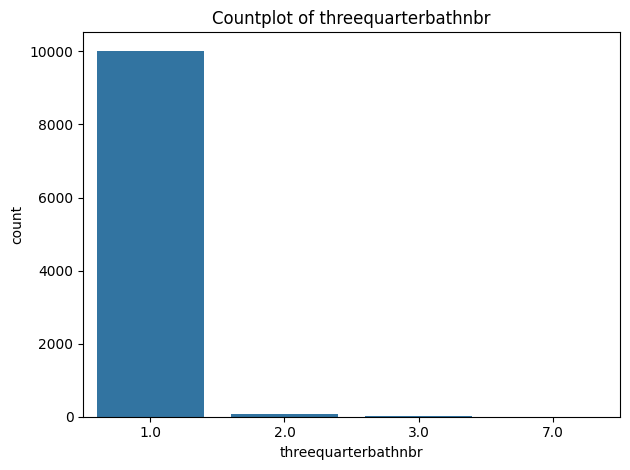

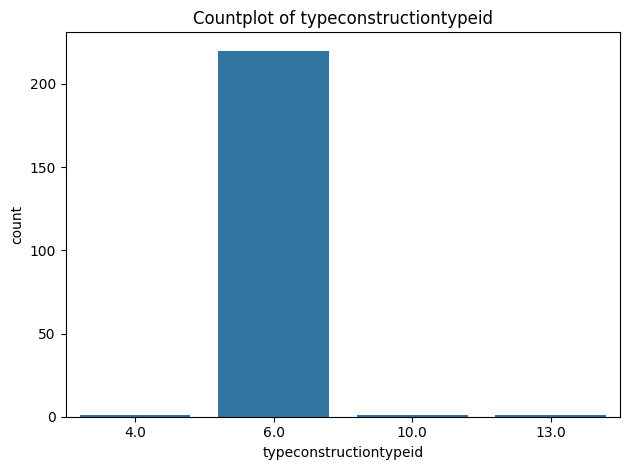

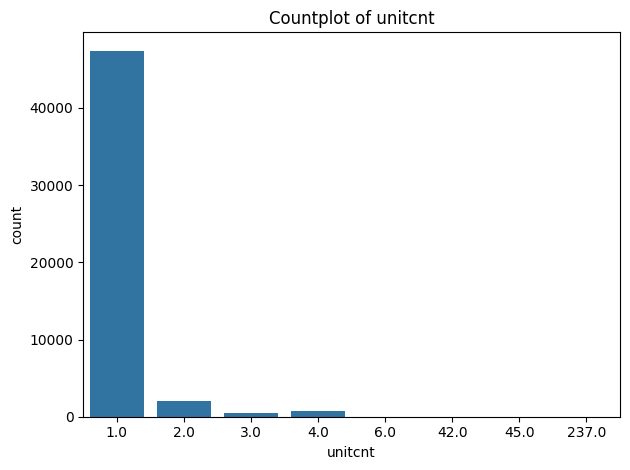

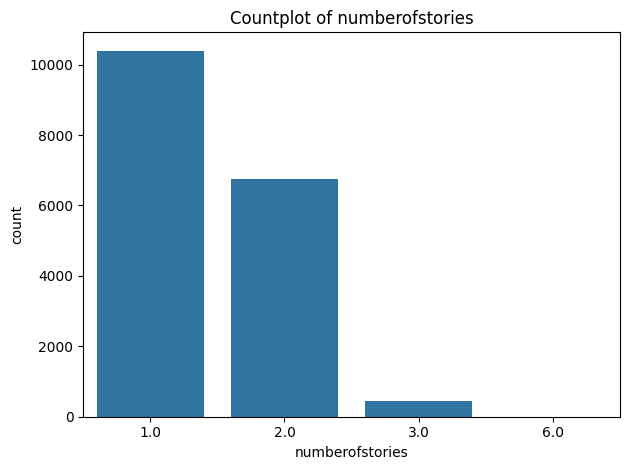

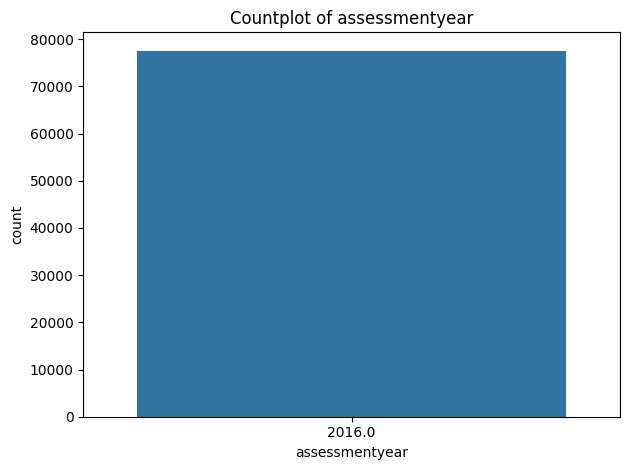

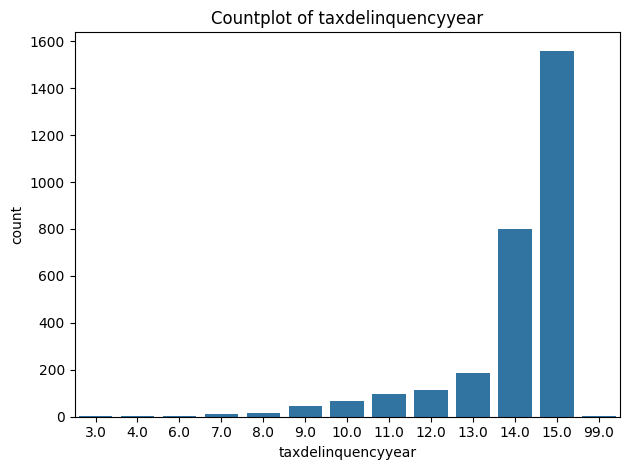

In [46]:
plt.figure(figsize=(14, 16))

for col in cat_cols:
        sns.countplot(
        data=df,
        x=col
        )

    
        plt.title(f"Countplot of {col}")
        plt.tight_layout()
        plt.show()

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


There are a number of odd features in this dataset. 

Distributions relating to continuous numerical variables, such as finishedsquarefeet12, were lightly right-skewed with the potential to have significant outliers.

There are a number of problems with null values as we can see from the significant discrepancies in y-axis scale between features as well as from our initial null calculation. 

A number of categorical columns have only a single value - for example, hashottuborspa only has a singular unique value. Typically, a binary field would have one value for true and one value for false, whereas this feature only has a True value. This is the case for quite a few features and will require some effort to correct. 

It also stuck out to us that there are a number of categorical columns that are systematically numerical and are stored as IDs without any index available to provide any insight into their effects on property value.

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [59]:
df["propertyzoningdesc"].nunique()

1907

In [ ]:

cols_to_drop = [
    #Identifiers
    'parcelid', 'rawcensustractandblock', 'censustractandblock',
    'propertylandusetypeid', 'propertycountylandusecode', "propertyzoningdesc",
    
    #Redundant pool features
    'pooltypeid10', 'pooltypeid2', 'pooltypeid7',
    
    #Construction-style encoded categories
    'architecturalstyletypeid', 'buildingclasstypeid',
    'typeconstructiontypeid', 'storytypeid', "buildingqualitytypeid", "airconditioningtypeid", "heatingorsystemtypeid",
    
    #Useless
    'taxdelinquencyflag', 'taxdelinquencyyear'
    ]


In [80]:
df_drop_features = df.drop(columns=cols_to_drop)

#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 


We have decided to drop a wide range of features from our dataframe to allow our eventual ML model to accurately and efficiently predit the target taxvaluedollarcnt variable.

We are first dropping identifiers that have no inherent relationship to value. This includes ParcelID, Rawcensustractandblock, and censustractandblock. These are IDs that do not generalize and will really only input noise into a ML model. ParcelID specifically would really only be useful in the context of linking datasets or identifying duplicate properties.

We drop some pool features that we've found to be redundant. Pooltypeid10 indicates whether the property has a hot tub or a spa which is already shown in hashottuborspa, Pooltypeid2 indicates if the property has a pool with a hot tub or spa, and Pooltypeid7 indicates if the property has a pool without a hot tub or spa. This is offering too granular of a view in a generally unclean manner, which we predict will simply overcomplicate our cleaning processes and overall model with very little utility. 

We also drop land use/jurisdiction codes such as propertylandusetypeid, propertycountylandusecode, and propertyzoningdesc, which not only overlap with more useful geographic region features such as zip code, city and county, but will not provide our model with any useful signal without any sort of index mapping on their meanings.

Similarly, we drop construction/architecture type IDs that really lack any context without mapping - as they are, they are meaningless numerical categories that our model will not be able to interpret: among these are architecturalstyletypeid, buildingclasstypeid, typeconstructiontypeid, buildingqualitytypeid, and airconditioningtypeid, amoung others.

Lastly, we drop taxdelinquencyflag and taxdelinquencyyear, which do not represent property characteristics, but rather owner behavior.




### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [81]:
df_drop_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   basementsqft                  50 non-null     float64
 1   bathroomcnt                   77579 non-null  float64
 2   bedroomcnt                    77579 non-null  float64
 3   calculatedbathnbr             76963 non-null  float64
 4   decktypeid                    614 non-null    float64
 5   finishedfloor1squarefeet      6037 non-null   float64
 6   calculatedfinishedsquarefeet  77378 non-null  float64
 7   finishedsquarefeet12          73923 non-null  float64
 8   finishedsquarefeet13          42 non-null     float64
 9   finishedsquarefeet15          3027 non-null   float64
 10  finishedsquarefeet50          6037 non-null   float64
 11  finishedsquarefeet6           386 non-null    float64
 12  fips                          77579 non-null  float64
 13  f

In [82]:

null_rates = df_drop_features.isnull().mean().sort_values(ascending=False)

null_rates_df = (null_rates * 100).round(2).to_frame(name="null_percent")
print("Null Rate for Each Feature:")
display(null_rates_df)

#Setting a threshold for percent of null values
threshold = 0.80

#Get features that exceed the threshold
cols_to_drop_nulls = null_rates[null_rates > threshold].index.tolist()

#Drop
df_drop = df_drop_features.drop(columns=cols_to_drop_nulls)


Null Rate for Each Feature:


,null_percent
finishedsquarefeet13,99.95
basementsqft,99.94
finishedsquarefeet6,99.50
decktypeid,99.21
poolsizesum,98.88
finishedsquarefeet15,96.10
finishedfloor1squarefeet,92.22
finishedsquarefeet50,92.22
fireplacecnt,89.32
threequarterbathnbr,86.98


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped




#I Have not yet done what I lay out below - I have just set the threshold and continued the coding. I am going to revisit this once I've banged out everything else.

We set a threshold of 60% NULL values to be dropped. This is a rigid threshold that will drop features that are of no use due to null values. This does immediately draw some concern, nontheless, when we look at the null percentages on each feature. For example, the fireplacecnt has a null rate of 89.32%, which screams to us that it should not be include - this is nuanced - it could be that only 11% of properties have any fireplace at all and when we look at the count plot of fireplacecnt, we see that there is no 0 value (indicator of no fireplace). What this tells us is that the null values have value; they represent that this property does not have a fireplace - what we can do from there is perform a constant imputation on null values for this field with the constant = 0. This applies to a few of these features, including poolcnt and garagecnt. What we've decided to do is first cherry-pick these features out, then set a more aggressive threshold (i.e., 60%) to exclude features with too many nulls. This will allow the largely null features with useful null values to be imputed with a constant.

### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [83]:
df_null_target = df_drop[df_drop["taxvaluedollarcnt"].notnull()] 

In [84]:
df_null_target.info()

<class 'pandas.core.frame.DataFrame'>
Index: 77578 entries, 0 to 77612
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   bathroomcnt                   77578 non-null  float64
 1   bedroomcnt                    77578 non-null  float64
 2   calculatedbathnbr             76962 non-null  float64
 3   calculatedfinishedsquarefeet  77377 non-null  float64
 4   finishedsquarefeet12          73922 non-null  float64
 5   fips                          77578 non-null  float64
 6   fullbathcnt                   76962 non-null  float64
 7   garagecarcnt                  25519 non-null  float64
 8   garagetotalsqft               25519 non-null  float64
 9   latitude                      77578 non-null  float64
 10  longitude                     77578 non-null  float64
 11  lotsizesquarefeet             69320 non-null  float64
 12  poolcnt                       16173 non-null  float64
 13  region

In [85]:

row_non_null_threshold = 0.70           # adjust if needed

#row-wise % of non-null features
row_non_null_rate = df_null_target.notnull().mean(axis=1)

#keep these
rows_to_keep = row_non_null_rate >= row_non_null_threshold

print("Rows removed due to too many nulls:", (~rows_to_keep).sum())
df_null_row_drop = df_null_target[rows_to_keep]


Rows removed due to too many nulls: 711


In [86]:
target = 'taxvaluedollarcnt'

Q1 = df_null_row_drop[target].quantile(0.25)
Q3 = df_null_row_drop[target].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

#identify outliers
outliers = (df_null_row_drop[target] < lower_bound) | (df_null_row_drop[target] > upper_bound)
print("Outliers removed:", outliers.sum())

#drop
df2 = df_null_row_drop[~outliers]

Outliers removed: 5101


#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


What we did here was look at the percentage of non null features in each row - we set an intital threshold of 70% of the features on a single row having non-null values. This is adjustable at any point - one caveat is that this occurs prior to our imputation step, so if the hashottuborspa feature is null and that null should really be representing that the property does not have a hot tub or spa, that null will be counted for a sample meeting or not meeting the threshold. What this means is that we should be setting a more liberal threshold that takes into account that those nulls should not be considered nulls. 

We also identify outliers within our target variable, which were already evident from our EDA histogram on this outcome. To do this - we used the IQR method, defining a lower and upper bound for the target variable and dropping those that fall outside that range.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [ ]:

numeric_cols = df2.select_dtypes(include=["int64", "float64"]).columns

#Like before I'm setting the threshold at 30 - this ensures a feature like number of bathrooms that can get split out into quarters is categorical - any continuous non-null feature should not be affected
numeric_categoricals = [
    col for col in numeric_cols
    if df2[col].nunique() <= 30
]

#Truly numeric (continuous) features
numeric_true = [col for col in numeric_cols if col not in numeric_categoricals]

#Regular categorical columns
cat_cols = (
    df2.select_dtypes(include=["object", "category"]).columns.tolist()
    + numeric_categoricals
)

#preserve ordering
cat_cols = list(dict.fromkeys(cat_cols))


#Impute numerical cateogircal columns with mode
for col in numeric_categoricals:
    df2[col] = df2[col].fillna(df2[col].mode().iloc[0])


#For special case columns - impute with 0
numeric_zero_cols = [col for col in ['garagecarcnt', 'hashottuborspa', 'poolcnt', 'fireplacecnt'] if col in df2.columns]

for col in numeric_zero_cols:
    df2[col] = df2[col].fillna(0)

#Remove the above special cases from them from numeric columns if they exist there
numeric_true = [col for col in numeric_true if col not in numeric_zero_cols]


#Impute truly numeric features (i.e., SQFT) with median
df2[numeric_true] = df2[numeric_true].fillna(df2[numeric_true].median())


#Import truly categorical features (objects) with unknown
string_cols = df2.select_dtypes(include=["object"]).columns
df2[string_cols] = df2[string_cols].fillna("Unknown")

print("Remaining null values:", df2.isnull().sum().sum())



Remaining null values: 0


C:\Users\jarodcastro\AppData\Local\Temp\ipykernel_26116\4027813702.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[col] = df2[col].fillna(df2[col].mode().iloc[0])
C:\Users\jarodcastro\AppData\Local\Temp\ipykernel_26116\4027813702.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[col] = df2[col].fillna(0)
C:\Users\jarodcastro\AppData\Local\Temp\ipykernel_26116\4027813702.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

In [88]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71766 entries, 0 to 77612
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   bathroomcnt                   71766 non-null  float64
 1   bedroomcnt                    71766 non-null  float64
 2   calculatedbathnbr             71766 non-null  float64
 3   calculatedfinishedsquarefeet  71766 non-null  float64
 4   finishedsquarefeet12          71766 non-null  float64
 5   fips                          71766 non-null  float64
 6   fullbathcnt                   71766 non-null  float64
 7   garagecarcnt                  71766 non-null  float64
 8   garagetotalsqft               71766 non-null  float64
 9   latitude                      71766 non-null  float64
 10  longitude                     71766 non-null  float64
 11  lotsizesquarefeet             71766 non-null  float64
 12  poolcnt                       71766 non-null  float64
 13  region

In [89]:
df2.head()

,bathroomcnt,bedroomcnt,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fullbathcnt,garagecarcnt,garagetotalsqft,latitude,...,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,unitcnt,yearbuilt,numberofstories,assessmentyear,taxvaluedollarcnt
0,3.5,4.0,3.5,3100.0,3100.0,6059.0,3.0,2.0,633.0,33634931.0,...,53571.0,1286.0,118849.0,96978.0,0.0,1.0,1998.0,1.0,2016.0,1023282.0
1,1.0,2.0,1.0,1465.0,1465.0,6111.0,1.0,1.0,0.0,34449266.0,...,13091.0,2061.0,118849.0,97099.0,5.0,1.0,1967.0,1.0,2016.0,464000.0
2,2.0,3.0,2.0,1243.0,1243.0,6059.0,2.0,2.0,440.0,33886168.0,...,21412.0,1286.0,118849.0,97078.0,6.0,1.0,1962.0,1.0,2016.0,564778.0
3,3.0,4.0,3.0,2376.0,2376.0,6037.0,3.0,2.0,0.0,34245180.0,...,396551.0,3101.0,118849.0,96330.0,0.0,1.0,1970.0,1.0,2016.0,145143.0
4,3.0,3.0,3.0,1312.0,1312.0,6037.0,3.0,2.0,0.0,34185120.0,...,12447.0,3101.0,268548.0,96451.0,0.0,1.0,1964.0,1.0,2016.0,119407.0


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


The data has proved to be pretty complex imputation-wise. The main reason for this is that simply identifying numerical vs. categorical features does not work since many of the features identified through (numeric_cols = df2.select_dtypes(include=["int64", "float64"]).columns) are categorical in nature. Why this is important is that if we take the median for all numerical features listed in that approach, we will get poor imputations for columns such as bedroomcnt that would benefit most from a mode imputation. This makes it important to separate those out into their own category (we did this for the EDA too). The method we used here considers any feature with < 30 unique values to be categorical, which we chose based on looking at the number of unique values by feature and manually identifying where the cutoff should be. 30 was ultimately chosen because the final discrete numerical feature that behaves categorically was bathroomcnt, which gets broken out into quarters and had 27 total unique values. 

Nonetheless, our imputation was pretty basic:
Mode Imputation - we used mode imputation on these discrete numerical features that behave categorically. This is useful as it will input null records with the most common value.

Median Imputation - we used median imputation on the continuous numerical features (i.e., SQFT). We thought this would be more useful than mean imputation since the distibutions of our continuous variables were visually right-skewed, and while this method can have a negative effect on capturing patterns, it's robust to skewed data. 

Constant Value Imputation - we used this as previously noted. CV Imputation is useful for the features where nulls represent a value of 0; for features such as hashottuborspa, fireplacecnt, or poolcnt, the null represents that the property has 0. We manually identify these in our code.

"Unknown" Imputation - we've imputed "unknown" into any features that are inherently categorical (dtype object). Imputing a numerical value into a column where a string is appropriate does not make sense, so this is the best alternative.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [97]:
df_final = pd.get_dummies(df2, columns=cat_cols, drop_first=True)
print("Final df shape:", df_final.shape)
df_final.head()


Final df shape: (71766, 102)


,calculatedfinishedsquarefeet,finishedsquarefeet12,garagetotalsqft,latitude,longitude,lotsizesquarefeet,regionidcity,regionidneighborhood,regionidzip,yearbuilt,...,roomcnt_12.0,unitcnt_2.0,unitcnt_3.0,unitcnt_4.0,unitcnt_6.0,unitcnt_42.0,unitcnt_45.0,numberofstories_2.0,numberofstories_3.0,numberofstories_6.0
0,3100.0,3100.0,633.0,33634931.0,-117869207.0,4506.0,53571.0,118849.0,96978.0,1998.0,...,False,False,False,False,False,False,False,False,False,False
1,1465.0,1465.0,0.0,34449266.0,-119281531.0,12647.0,13091.0,118849.0,97099.0,1967.0,...,False,False,False,False,False,False,False,False,False,False
2,1243.0,1243.0,440.0,33886168.0,-117823170.0,8432.0,21412.0,118849.0,97078.0,1962.0,...,False,False,False,False,False,False,False,False,False,False
3,2376.0,2376.0,0.0,34245180.0,-118240722.0,13038.0,396551.0,118849.0,96330.0,1970.0,...,False,False,False,False,False,False,False,False,False,False
4,1312.0,1312.0,0.0,34185120.0,-118414640.0,278581.0,12447.0,268548.0,96451.0,1964.0,...,False,False,False,False,False,False,False,False,False,False


In [96]:
df_final.info(max_cols=None)

<class 'pandas.core.frame.DataFrame'>
Index: 71766 entries, 0 to 77612
Columns: 102 entries, calculatedfinishedsquarefeet to numberofstories_6.0
dtypes: bool(91), float64(11)
memory usage: 12.8 MB


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?



### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

